C:\Users\campus4D023\AppData\Local\Temp\ipykernel_24320\1553023281.py:22: LangChainDeprecationWarning: The class `Ollama` was deprecated in LangChain 0.3.1 and will be removed in 1.0.0. An updated version of the class exists in the :class:`~langchain-ollama package and should be used instead. To use it run `pip install -U :class:`~langchain-ollama` and import as `from :class:`~langchain_ollama import OllamaLLM``.
  llm = Ollama(model="exaone3.5:7.8b")


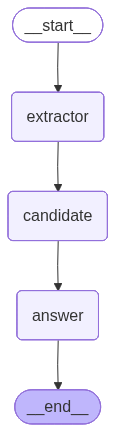

============================== LangGraph 구조:
+-----------+  
| __start__ |  
+-----------+  
      *        
      *        
      *        
+-----------+  
| extractor |  
+-----------+  
      *        
      *        
      *        
+-----------+  
| candidate |  
+-----------+  
      *        
      *        
      *        
  +--------+   
  | answer |   
  +--------+   
      *        
      *        
      *        
 +---------+   
 | __end__ |   
 +---------+   


In [ ]:
from langchain_community.llms import Ollama
from langchain_core.prompts import PromptTemplate
from langgraph.graph import StateGraph, END
from typing import TypedDict


# ============================================
# 1. 상태 정의
# ============================================

class AgentState(TypedDict, total=False):
    query: str                  # 사용자 질문
    symptoms: str               # 추출된 증상 / 상태
    exercise_candidates: str    # 추천 운동 후보
    result: str                 # 최종 답변


# ============================================
# 2. LLM 초기화
# ============================================

llm = Ollama(model="exaone3.5:7.8b")


# ============================================
# 3. 추출 에이전트
# 사용자의 질문에서 증상 또는 고민 상태 추출
# ============================================

extractor_prompt = PromptTemplate.from_template("""
사용자의 질문에서 운동 추천에 필요한 증상 또는 고민 상태를 추출하세요.

조건:
- 핵심 증상 또는 고민만 추출하세요.
- 결과는 쉼표로 구분된 문자열로 출력하세요.
- 설명 문장은 쓰지 마세요.

질문: {query}
""")


def extractor_agent(state: AgentState):
    chain = extractor_prompt | llm

    symptoms = chain.invoke({
        "query": state["query"]
    })

    return {
        **state,
        "symptoms": symptoms.strip()
    }


# ============================================
# 4. 후보 에이전트
# 추출된 증상/고민을 해결할 수 있는 운동 리스트 생성
# ============================================

candidate_prompt = PromptTemplate.from_template("""
다음 사용자의 증상 또는 고민 상태를 바탕으로 도움이 될 수 있는 운동을 추천하세요.

증상 또는 고민:
{symptoms}

조건:
- 초보자도 시작할 수 있는 운동을 중심으로 추천하세요.
- 무리한 고강도 운동은 피하세요.
- 운동 이름만 쉼표로 구분해서 출력하세요.
- 운동은 4~6개 정도 추천하세요.
""")


def candidate_agent(state: AgentState):
    chain = candidate_prompt | llm

    exercise_candidates = chain.invoke({
        "symptoms": state["symptoms"]
    })

    return {
        **state,
        "exercise_candidates": exercise_candidates.strip()
    }


# ============================================
# 5. 답변 생성 에이전트
# 증상과 운동 리스트를 바탕으로 최종 답변 생성
# ============================================

answer_prompt = PromptTemplate.from_template("""
사용자의 고민 상태는 다음과 같습니다.

[증상 또는 고민]
{symptoms}

[추천 운동 리스트]
{exercise_candidates}

위 내용을 바탕으로 사용자에게 운동 추천 답변을 작성하세요.

조건:
- 반드시 한국어로 작성하세요.
- 개조식으로 작성하세요.
- 운동별 추천 이유를 간단히 작성하세요.
- 처음 운동을 시작하는 사람 기준으로 설명하세요.
- 무리하지 말고 점진적으로 시작하라는 주의사항을 포함하세요.
- 의학적 진단처럼 단정하지 마세요.
""")


def answer_agent(state: AgentState):
    chain = answer_prompt | llm

    answer = chain.invoke({
        "symptoms": state["symptoms"],
        "exercise_candidates": state["exercise_candidates"]
    })

    return {
        **state,
        "result": answer.strip()
    }


# ============================================
# 6. LangGraph 정의
# ============================================

graph = StateGraph(AgentState)

graph.add_node("extractor", extractor_agent)
graph.add_node("candidate", candidate_agent)
graph.add_node("answer", answer_agent)

graph.set_entry_point("extractor")

graph.add_edge("extractor", "candidate")
graph.add_edge("candidate", "answer")
graph.add_edge("answer", END)

app = graph.compile()


# ============================================
# 7. 그래프 구조 시각화
# ============================================

from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

print("============================== LangGraph 구조:")
app.get_graph().print_ascii()


# ============================================
# 8. 실행 예시
# ============================================

query = "체력이 안 좋고, 살이 계속 찌는데 어떤 운동을 할까?"

result = app.invoke({
    "query": query
})

print("============================== 추출된 증상:")
print(result["symptoms"])

print("============================== 운동 후보:")
print(result["exercise_candidates"])

print("============================== 최종 응답:")
print(result["result"])